# Лабораторная работа №2

## Тема: Расширенный статистический анализ и методы машинного обучения на данных о Нобелевских лауреатах

**Источник данных:** `laureates.json` из [API Nobel Prize](`https://api.nobelprize.org/2.1/laureates`).

**Объем данных:** 1018 лауреатов и 1026 присужденных премий.

**Авторы:** Григорий Зайка, Артур Мамалига, Анатолий Курилов.

**Группа:** I2302.

Целью данной работы является выявление статистических закономерностей и зависимостей в данных о Нобелевских лауреатах, а также моделирование взаимосвязей между датой рождения лауреата, годом присуждения премии и суммой премии. Для этого применяются методы разведочного и инференциального статистического анализа, а также алгоритмы машинного обучения (регрессия, классификация, PCA и временные модели), позволяющие формализовать влияние факторов, проверять гипотезы и осуществлять прогнозирование характеристик присуждения премий.

### Структура работы

1. Введение и описание данных.
2. Предобработка, очистка и построение признаков.
3. Разведочный анализ данных и визуализации.
4. Регрессионная и классификационная модели.
5. PCA и анализ временного ряда.
6. Интерпретация результатов, ограничения и рекомендации.
7. Библиография и вклад участников.

### Распределение ролей

- Григорий Зайка - постановка задачи, сбор данных и предобработка.
- Артур Мамалига - EDA и визуализация.
- Анатолий Курилов - модели регрессии, классификации, PCA и ARIMA.

### Почему выбран именно этот набор данных

Данные о Нобелевских лауреатах подходят для полной аналитической цепочки: в них есть категориальные и числовые признаки, временная составляющая по годам премий, пропуски, выбросы, а также естественные задачи для регрессии, классификации, снижения размерности и анализа временного ряда.

### Структура данных из CSV (`laureates.json`)

Ниже приведена структура основной аналитической таблицы, с которой выполняется большая часть анализа.

| Поле                            | Тип данных   | Понятное объяснение                                                                                                                 |
| ------------------------------- | ------------ | ----------------------------------------------------------------------------------------------------------------------------------- |
| **laureate_id**                 | строка/число | Уникальный номер лауреата в базе данных.                                           |
| **file_name**                   | строка       | Имя записи в файле или источнике данных.                            |
| **gender**                      | строка       | Пол человека                                                                           |
| **known_name**                  | строка       | Имя, под которым человек наиболее известен                                                  |
| **full_name**                   | строка       | Полное официальное имя человека                                                                      |
| **birth_date**                  | строка       | Дата рождения в полном формате (день, месяц, год), например: 12-03-1950.                                                            |
| **birth_year**                  | число        | Год рождения (например: 1950).                                                        |
| **birth_country**               | строка       | Страна человека на момент его рождения (может быть исторической, например СССР).                                  |
| **birth_country_now**           | строка       | Та же территория, но уже в современных границах (например: Россия вместо СССР).                                                     |
| **birth_continent**             | строка       | Континент, на котором родился человек (Европа, Азия и т.д.).                                                                        |
| **birth_location**              | строка       | Полное место рождения одной строкой (город + страна).                                                                        |
| **death_year**                  | число        | Год смерти человека (если он умер)                                                      |
| **prize_count**                 | число        | Сколько раз человек получал Нобелевскую премию                                                            |
| **first_award_year**            | число        | Год, когда человек впервые получил Нобелевскую премию.                                                                              |
| **first_category**              | строка       | Категория первой премии (например: Physics - физика, Chemistry - химия, Peace - мир и т.д.).                                        |
| **first_prize_amount_adjusted** | число        | Денежная сумма первой премии в долларах, пересчитанная с учётом инфляции |
| **first_motivation**            | строка       | Официальная формулировка, за что именно была присуждена премия (текстовое описание причины).                                        |
| **first_affiliation_name**      | строка       | Название организации, в которой работал лауреат на момент получения премии                     |
| **first_affiliation_city**      | строка       | Город, где находится эта организация.                                                                                               |
| **first_award_country**         | строка       | Страна, с которой связан лауреат на момент получения премии (обычно страна его организации).                                        |
| **first_award_continent**       | строка       | Континент этой страны (например: Европа, Северная Америка).                                                                         |
| **is_science**                  | 0/1          | Показывает, относится ли премия к науке: 1 - да (физика, химия, медицина), 0 - нет (литература, мир, экономика).                    |


Дополнительно в ноутбуке используется `nobel_prizes_long.csv` - длинная таблица по всем премиям, где одна строка соответствует одной награде.

## II. Обработка и отчистка датасета.
Этот этап включает в себя извлечение данных из JSON-файла, их структурирование в таблицы (DataFrame),<br>
обработку пропусков и приведение признаков к числовому виду с последующим переводом категориальных переменных на русский язык для удобства дальнейшего анализа.

In [29]:
from pathlib import Path
import json
import subprocess
import sys
import warnings

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "pandas",
        "numpy",
        "matplotlib",
        "seaborn",
        "scikit-learn",
        "statsmodels",
    ]
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

DATA_PATH = Path("laureates.json")
SCIENTIFIC_CATEGORIES = {
    "Physics",
    "Chemistry",
    "Physiology or Medicine",
    "Economic Sciences",
}

with DATA_PATH.open(encoding="utf-8") as handle:
    raw_data = json.load(handle)


def first_item(value):
    if isinstance(value, list) and value:
        return value[0]
    return {}


def nested_value(mapping, *keys):
    current = mapping
    for key in keys:
        if not isinstance(current, dict):
            return None
        current = current.get(key)
    return current


laureate_records = []
prize_records = []

for source_row in raw_data["laureates"]:
    laureate_id = source_row.get("id")
    file_name = source_row.get("fileName")
    gender = source_row.get("gender")
    known_name = nested_value(source_row, "knownName", "en")
    full_name = nested_value(source_row, "fullName", "en")
    birth_date = nested_value(source_row, "birth", "date")
    birth_year = pd.to_numeric(nested_value(source_row, "birth", "year"), errors="coerce")
    birth_country = nested_value(source_row, "birth", "place", "country", "en")
    birth_country_now = nested_value(source_row, "birth", "place", "countryNow", "en")
    birth_continent = nested_value(source_row, "birth", "place", "continent", "en")
    birth_location = nested_value(source_row, "birth", "place", "locationString", "en")
    death_date = nested_value(source_row, "death", "date")
    death_year = pd.to_numeric(str(death_date).split("-")[0], errors="coerce") if death_date else np.nan
    prizes = source_row.get("nobelPrizes", []) or []
    prize_count = len(prizes)
    first_prize = prizes[0] if prizes else {}
    first_award_year = pd.to_numeric(first_prize.get("awardYear"), errors="coerce")
    first_category = nested_value(first_prize, "category", "en")
    first_prize_amount = pd.to_numeric(first_prize.get("prizeAmountAdjusted"), errors="coerce")
    first_motivation = nested_value(first_prize, "motivation", "en")
    first_affiliation = first_item(first_prize.get("affiliations"))
    first_residence = first_item(first_prize.get("residences"))
    first_award_country = (
        nested_value(first_affiliation, "countryNow", "en")
        or nested_value(first_affiliation, "country", "en")
        or nested_value(first_residence, "countryNow", "en")
        or nested_value(first_residence, "country", "en")
    )
    first_award_continent = nested_value(first_affiliation, "continent", "en") or nested_value(first_residence, "continent", "en")
    first_affiliation_name = nested_value(first_affiliation, "name", "en")
    first_affiliation_city = nested_value(first_affiliation, "cityNow", "en") or nested_value(first_affiliation, "city", "en")
    first_is_science = int(first_category in SCIENTIFIC_CATEGORIES) if pd.notna(first_category) else np.nan

    laureate_records.append(
        {
            "laureate_id": laureate_id,
            "file_name": file_name,
            "gender": gender,
            "known_name": known_name,
            "full_name": full_name,
            "birth_date": birth_date,
            "birth_year": birth_year,
            "birth_country": birth_country,
            "birth_country_now": birth_country_now,
            "birth_continent": birth_continent,
            "birth_location": birth_location,
            "death_year": death_year,
            "prize_count": prize_count,
            "first_award_year": first_award_year,
            "first_category": first_category,
            "first_prize_amount_adjusted": first_prize_amount,
            "first_motivation": first_motivation,
            "first_affiliation_name": first_affiliation_name,
            "first_affiliation_city": first_affiliation_city,
            "first_award_country": first_award_country,
            "first_award_continent": first_award_continent,
            "is_science": first_is_science,
        }
    )

    for prize_index, prize in enumerate(prizes, start=1):
        award_year = pd.to_numeric(prize.get("awardYear"), errors="coerce")
        category = nested_value(prize, "category", "en")
        prize_amount = pd.to_numeric(prize.get("prizeAmountAdjusted"), errors="coerce")
        motivation = nested_value(prize, "motivation", "en")
        affiliation = first_item(prize.get("affiliations"))
        residence = first_item(prize.get("residences"))
        award_country = (
            nested_value(affiliation, "countryNow", "en")
            or nested_value(affiliation, "country", "en")
            or nested_value(residence, "countryNow", "en")
            or nested_value(residence, "country", "en")
        )
        award_continent = nested_value(affiliation, "continent", "en") or nested_value(residence, "continent", "en")
        prize_records.append(
            {
                "laureate_id": laureate_id,
                "file_name": file_name,
                "gender": gender,
                "known_name": known_name,
                "full_name": full_name,
                "birth_year": birth_year,
                "award_year": award_year,
                "category": category,
                "prize_amount_adjusted": prize_amount,
                "motivation": motivation,
                "affiliation_name": nested_value(affiliation, "name", "en"),
                "affiliation_city": nested_value(affiliation, "cityNow", "en") or nested_value(affiliation, "city", "en"),
                "award_country": award_country,
                "award_continent": award_continent,
                "prize_index": prize_index,
                "is_science": int(category in SCIENTIFIC_CATEGORIES) if pd.notna(category) else np.nan,
            }
        )

laureate_df = pd.DataFrame(laureate_records)
prize_df = pd.DataFrame(prize_records)

laureate_df.to_csv("nobel_laureates.csv", index=False, encoding="utf-8")
prize_df.to_csv("nobel_prizes_long.csv", index=False, encoding="utf-8")

category_ru = {
    "Physics": "Физика",
    "Chemistry": "Химия",
    "Physiology or Medicine": "Физиология или медицина",
    "Peace": "Премия мира",
    "Literature": "Литература",
    "Economic Sciences": "Экономические науки",
}
gender_ru = {"male": "Мужчины", "female": "Женщины"}
continent_ru = {
    "Europe": "Европа",
    "Asia": "Азия",
    "North America": "Северная Америка",
    "South America": "Южная Америка",
    "Africa": "Африка",
    "Oceania": "Океания",
    "Unknown": "Неизвестно",
}
country_ru = {
    "USA": "США",
    "United Kingdom": "Великобритания",
    "Germany": "Германия",
    "France": "Франция",
    "Sweden": "Швеция",
    "Switzerland": "Швейцария",
    "Japan": "Япония",
    "Russia": "Россия",
    "Italy": "Италия",
    "Unknown": "Неизвестно",
}

preview_df = laureate_df.head(3).rename(columns={
    "laureate_id": "ID лауреата",
    "file_name": "Служебное имя записи",
    "gender": "Пол",
    "known_name": "Известное имя",
    "full_name": "Полное имя",
    "birth_date": "Дата рождения",
    "birth_year": "Год рождения",
    "birth_country": "Страна рождения (историческая)",
    "birth_country_now": "Страна рождения (современная)",
    "birth_continent": "Континент рождения",
    "birth_location": "Место рождения (полное)",
    "death_year": "Год смерти",
    "prize_count": "Количество премий",
    "first_award_year": "Год первой премии",
    "first_category": "Категория первой премии",
    "first_prize_amount_adjusted": "Сумма премии (USD, с учетом инфляции)",
    "first_motivation": "Причина награждения",
    "first_affiliation_name": "Организация лауреата",
    "first_affiliation_city": "Город организации",
    "first_award_country": "Страна организации (при награждении)",
    "first_award_continent": "Континент организации",
    "is_science": "Научная категория (1/0)",
})

preview_df["Пол"] = preview_df["Пол"].map(gender_ru)
preview_df["Категория первой премии"] = preview_df["Категория первой премии"].map(category_ru)
preview_df["Континент рождения"] = preview_df["Континент рождения"].map(continent_ru)
preview_df["Континент организации"] = preview_df["Континент организации"].map(continent_ru)

preview_df["Страна рождения (историческая)"] = preview_df["Страна рождения (историческая)"].map(country_ru).fillna(
    preview_df["Страна рождения (историческая)"]
)
preview_df["Страна рождения (современная)"] = preview_df["Страна рождения (современная)"].map(country_ru).fillna(
    preview_df["Страна рождения (современная)"]
)
preview_df["Страна организации (при награждении)"] = preview_df["Страна организации (при награждении)"].map(country_ru).fillna(
    preview_df["Страна организации (при награждении)"]
)

preview_df["Научная категория (1/0)"] = preview_df["Научная категория (1/0)"].map({1: "Да", 0: "Нет"})

print(f"Таблица лауреатов: {laureate_df.shape[0]} строк x {laureate_df.shape[1]} столбцов")
print(f"Таблица премий: {prize_df.shape[0]} строк x {prize_df.shape[1]} столбцов")
display(preview_df)

Таблица лауреатов: 1018 строк x 22 столбцов
Таблица премий: 1026 строк x 16 столбцов


,ID лауреата,Служебное имя записи,Пол,Известное имя,Полное имя,Дата рождения,Год рождения,Страна рождения (историческая),Страна рождения (современная),Континент рождения,Место рождения (полное),Год смерти,Количество премий,Год первой премии,Категория первой премии,"Сумма премии (USD, с учетом инфляции)",Причина награждения,Организация лауреата,Город организации,Страна организации (при награждении),Континент организации,Научная категория (1/0)
0,745,spence,Мужчины,A. Michael Spence,A. Michael Spence,1943-00-00,1943.0,США,США,Северная Америка,"Montclair, NJ, USA",NaN,1,2001,Экономические науки,15547541,for their analyses of markets with asymmetric ...,Stanford University,"Stanford, CA",США,Северная Америка,Да
1,102,bohr,Мужчины,Aage N. Bohr,Aage Niels Bohr,1922-06-19,1922.0,Denmark,Denmark,Европа,"Copenhagen, Denmark",2009.0,1,1975,Физика,4304697,for the discovery of the connection between co...,Niels Bohr Institute,Copenhagen,Denmark,Европа,Да
2,779,ciechanover,Мужчины,Aaron Ciechanover,Aaron Ciechanover,1947-10-01,1947.0,British Protectorate of Palestine,Israel,Азия,"Haifa, British Protectorate of Palestine (now ...",NaN,1,2004,Химия,14874529,for the discovery of ubiquitin-mediated protei...,Technion - Israel Institute of Technology,Haifa,Israel,Азия,Да


In [30]:
analysis_df = laureate_df.copy()

analysis_df["award_year_num"] = pd.to_numeric(analysis_df["first_award_year"], errors="coerce")
analysis_df["birth_year"] = pd.to_numeric(analysis_df["birth_year"], errors="coerce")
analysis_df["age_awarded"] = analysis_df["award_year_num"] - analysis_df["birth_year"]
analysis_df["prize_amount_log"] = np.log1p(analysis_df["first_prize_amount_adjusted"])
analysis_df["award_decade"] = (analysis_df["award_year_num"] // 10) * 10
analysis_df["continent_group"] = (
    analysis_df["first_award_continent"]
    .fillna(analysis_df["birth_continent"])
    .fillna("Неизвестно")
)
analysis_df["primary_country"] = (
    analysis_df["first_award_country"]
    .fillna(analysis_df["birth_country_now"])
    .fillna(analysis_df["birth_country"])
    .fillna("Неизвестно")
)
analysis_df["age_awarded_clipped"] = analysis_df["age_awarded"].clip(
    lower=analysis_df["age_awarded"].quantile(0.01),
    upper=analysis_df["age_awarded"].quantile(0.99),
)
analysis_df["primary_gender_code"] = analysis_df["gender"].map({"male": 0, "female": 1})
analysis_df["is_science"] = analysis_df["is_science"].fillna(0).astype(int)

gender_ru = {
    "male": "Мужчина",
    "female": "Женщина"
}

category_ru = {
    "Physics": "Физика",
    "Chemistry": "Химия",
    "Physiology or Medicine": "Физиология или медицина",
    "Peace": "Премия мира",
    "Literature": "Литература",
    "Economic Sciences": "Экономические науки"
}

continent_ru = {
    "Europe": "Европа",
    "Asia": "Азия",
    "North America": "Северная Америка",
    "South America": "Южная Америка",
    "Africa": "Африка",
    "Oceania": "Океания",
    "Unknown": "Неизвестно",
    "Неизвестно": "Неизвестно"
}


def format_describe(series: pd.Series) -> pd.DataFrame:
    stats = series.describe().rename(index={
        "count": "Количество",
        "mean": "Среднее",
        "std": "Стандартное отклонение",
        "min": "Минимум",
        "25%": "Q1",
        "50%": "Медиана",
        "75%": "Q3",
        "max": "Максимум",
    }).to_frame(name="Значение")

    if "Количество" in stats.index:
        stats.loc["Количество", "Значение"] = int(stats.loc["Количество", "Значение"])

    for idx in stats.index:
        if idx != "Количество" and pd.notna(stats.loc[idx, "Значение"]):
            stats.loc[idx, "Значение"] = round(float(stats.loc[idx, "Значение"]), 2)

    return stats


print(f"Сводка по качеству данных для {len(analysis_df)} лауреатов")

missing_summary = (
    analysis_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(12)
    .rename(index={
        "death_year": "Год смерти",
        "first_affiliation_city": "Город организации",
        "first_affiliation_name": "Организация лауреата",
        "first_award_continent": "Континент организации",
        "first_award_country": "Страна организации",
        "birth_country": "Страна рождения (историческая)",
        "birth_country_now": "Страна рождения (современная)",
        "birth_continent": "Континент рождения",
        "birth_location": "Место рождения",
        "full_name": "Полное имя",
        "gender": "Пол",
        "birth_year": "Год рождения",
    })
    .round(2)
    .to_frame(name="Доля пропусков, %")
)
display(missing_summary)

print("\nСводка возраста на момент награждения:")
display(format_describe(analysis_df["age_awarded"]))

print("\nСводка суммы премии в логарифмической шкале:")
display(format_describe(analysis_df["prize_amount_log"]))

print("\nПроверка выбросов по возрасту методом IQR:")
q1 = analysis_df["age_awarded"].quantile(0.25)
q3 = analysis_df["age_awarded"].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outlier_mask = analysis_df["age_awarded"].between(lower_fence, upper_fence, inclusive="both")
outlier_count = (
    outlier_mask.value_counts(dropna=False)
    .rename(index={True: "В пределах нормы", False: "Выбросы"})
    .to_frame(name="Количество")
)
outlier_count["Количество"] = outlier_count["Количество"].astype(int)
display(outlier_count)

print("\nПервые наблюдения по ключевым признакам:")
preview_table = analysis_df[["first_category", "gender", "continent_group"]].head(8).rename(columns={
    "first_category": "Категория",
    "gender": "Пол",
    "continent_group": "Континент",
})
preview_table["Категория"] = preview_table["Категория"].map(category_ru).fillna(preview_table["Категория"])
preview_table["Пол"] = preview_table["Пол"].map(gender_ru).fillna(preview_table["Пол"])
preview_table["Континент"] = preview_table["Континент"].map(continent_ru).fillna(preview_table["Континент"])
display(preview_table)

Сводка по качеству данных для 1018 лауреатов


,"Доля пропусков, %"
Год смерти,32.12
Город организации,26.52
Организация лауреата,26.03
Континент организации,4.22
Страна организации,4.13
Страна рождения (историческая),3.05
Страна рождения (современная),3.05
Континент рождения,3.05
Место рождения,3.05
Полное имя,2.75



Сводка возраста на момент награждения:


,Значение
Количество,990.00
Среднее,60.44
Стандартное отклонение,12.68
Минимум,17.00
Q1,52.00
Медиана,61.00
Q3,70.00
Максимум,97.00



Сводка суммы премии в логарифмической шкале:


,Значение
Количество,1018.00
Среднее,15.76
Стандартное отклонение,0.55
Минимум,14.92
Q1,15.18
Медиана,15.74
Q3,16.27
Максимум,16.56



Проверка выбросов по возрасту методом IQR:


,Количество
age_awarded,
В пределах нормы,989
Выбросы,29



Первые наблюдения по ключевым признакам:


,Категория,Пол,Континент
0,Экономические науки,Мужчина,Северная Америка
1,Физика,Мужчина,Европа
2,Химия,Мужчина,Азия
3,Химия,Мужчина,Европа
4,Литература,Мужчина,Неизвестно
5,Физика,Мужчина,Европа
6,Экономические науки,Мужчина,Северная Америка
7,Премия мира,Мужчина,Африка


### III. Анализ данных

На данном этапе проводится первичный анализ структуры набора данных.<br>
В ходе анализа рассматриваются распределения ключевых признаков, а также исследуются возможные взаимосвязи между ними.<br>
В частности, анализ направлен на ответы на следующие вопросы:<br>

- какие категории Нобелевских премий и страны представлены чаще всего;
- как изменялось количество присуждаемых премий во времени;
- существуют ли различия в возрасте лауреатов в зависимости от категории премии;
- какие числовые признаки демонстрируют наиболее сильные взаимосвязи.

Для оценки взаимосвязей между числовыми признаками применяется коэффициент корреляции Пирсона:

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum (x_i - \bar{x})^2 \cdot \sum (y_i - \bar{y})^2}}
$$



Описательная статистика по ключевым признакам


,Год рождения,Год первой премии,Возраст на момент награждения,"Сумма премии (USD, с учетом инфляции)",Количество премий
Количество,990.00,1018.00,990.00,1018.00,1018.00
Среднее,1914.41,1975.07,60.44,8064619.84,1.01
Стандартное отклонение,32.72,35.04,12.68,4104849.20,0.10
Минимум,1817.00,1901.00,17.00,3006134.00,1.00
Q1,1895.00,1950.00,52.00,3923237.00,1.00
Медиана,1919.50,1980.00,61.00,6845037.00,1.00
Q3,1940.00,2004.75,70.00,11603589.00,1.00
Максимум,1997.00,2025.00,97.00,15547541.00,3.00



Топ категорий


,Количество
category,
Физиология или медицина,232
Физика,230
Химия,200
Премия мира,143
Литература,122
Экономические науки,99



Топ стран


,Количество
primary_country,
США,431
Великобритания,118
Германия,85
Франция,64
Швеция,32
Швейцария,30
Неизвестно,27
Япония,24
Россия,19



Распределение по полу


,Количество
gender,
Мужчины,923
Женщины,67
Не указано,28


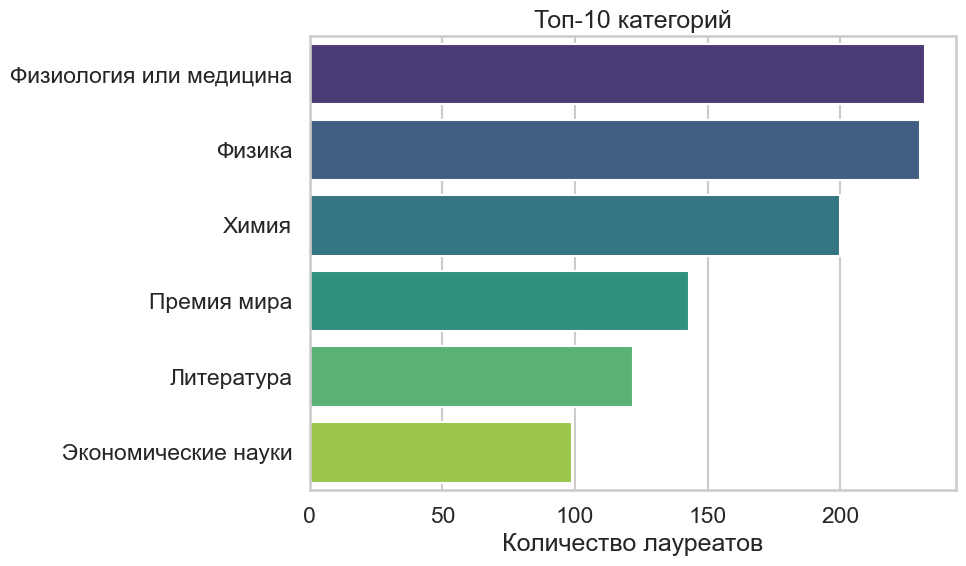

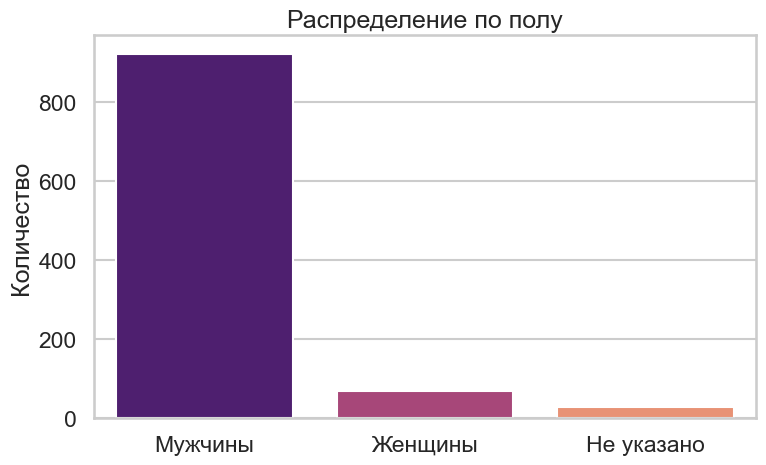

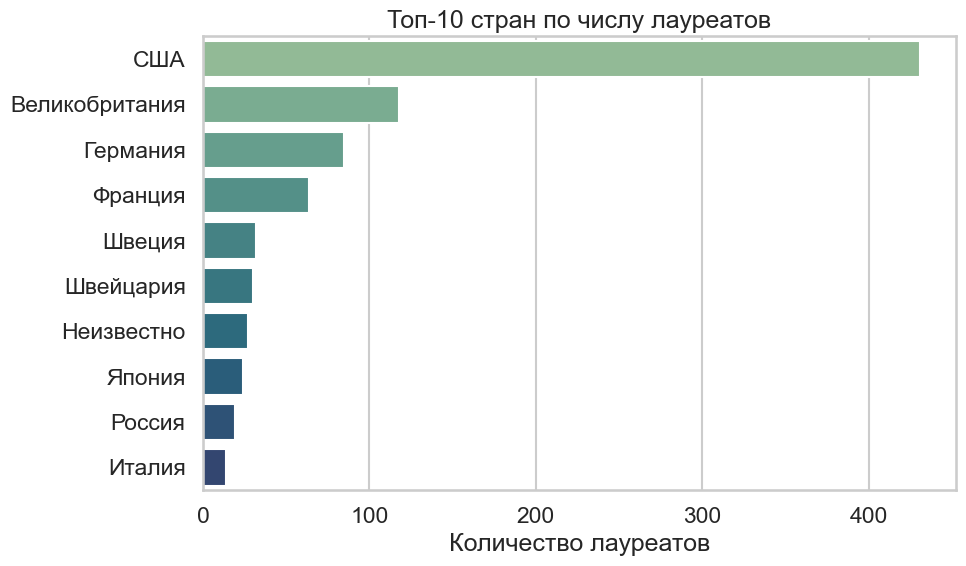

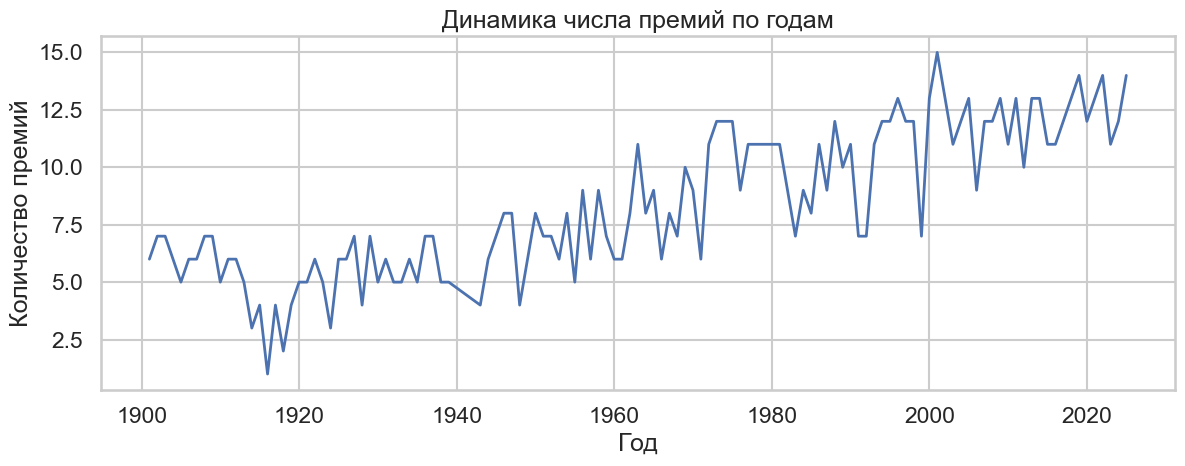

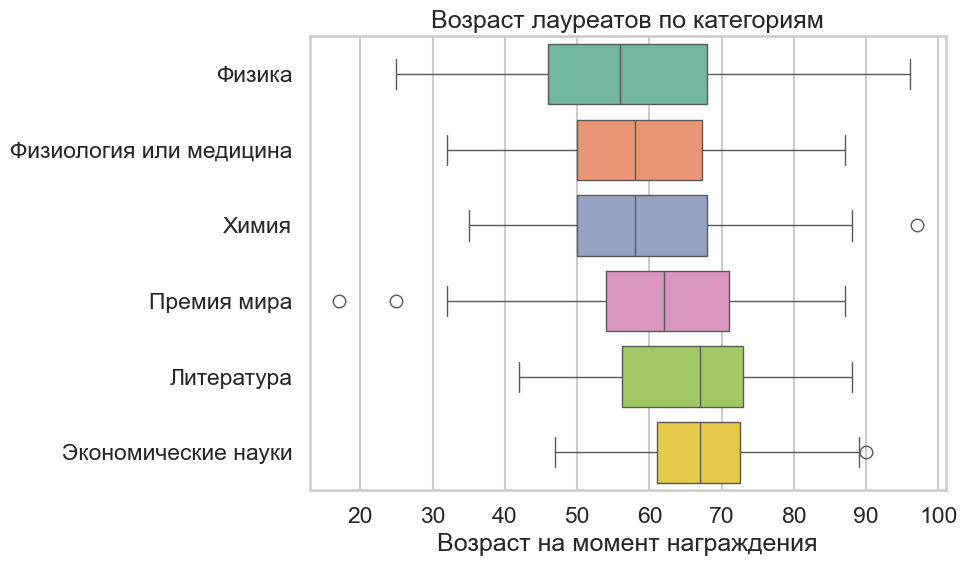

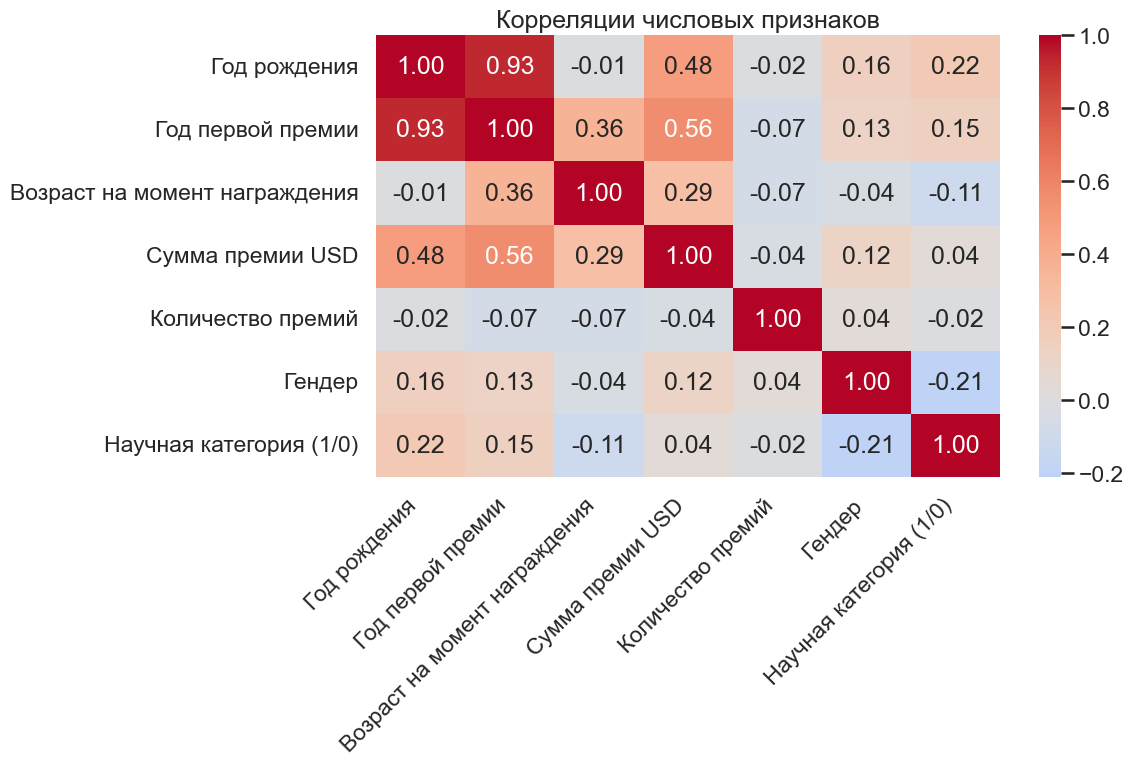

In [31]:
prize_eda = prize_df.copy()
prize_eda["award_year"] = pd.to_numeric(prize_eda["award_year"], errors="coerce")
prize_eda["primary_country"] = prize_eda["award_country"].fillna("Неизвестно")

category_ru = {
    "Physics": "Физика",
    "Chemistry": "Химия",
    "Physiology or Medicine": "Физиология или медицина",
    "Peace": "Премия мира",
    "Literature": "Литература",
    "Economic Sciences": "Экономические науки",
}

gender_ru = {
    "male": "Мужчины",
    "female": "Женщины",
}

country_ru = {
    "USA": "США",
    "United Kingdom": "Великобритания",
    "Germany": "Германия",
    "France": "Франция",
    "Sweden": "Швеция",
    "Switzerland": "Швейцария",
    "Japan": "Япония",
    "Russia": "Россия",
    "Italy": "Италия",
    "Canada": "Канада",
    "Austria": "Австрия",
    "Netherlands": "Нидерланды",
    "Denmark": "Дания",
    "Belgium": "Бельгия",
    "Norway": "Норвегия",
    "Israel": "Израиль",
    "India": "Индия",
    "China": "Китай",
    "Poland": "Польша",
    "Mexico": "Мексика",
    "Argentina": "Аргентина",
    "South Africa": "ЮАР",
    "Australia": "Австралия",
    "Неизвестно": "Неизвестно",
}

def format_descriptive_table(df: pd.DataFrame) -> pd.DataFrame:
    formatted = df.copy()
    formatted = formatted.rename(columns={
        "birth_year": "Год рождения",
        "first_award_year": "Год первой премии",
        "age_awarded": "Возраст на момент награждения",
        "first_prize_amount_adjusted": "Сумма премии (USD, с учетом инфляции)",
        "prize_count": "Количество премий",
    }).rename(index={
        "count": "Количество",
        "mean": "Среднее",
        "std": "Стандартное отклонение",
        "min": "Минимум",
        "25%": "Q1",
        "50%": "Медиана",
        "75%": "Q3",
        "max": "Максимум",
    })

    formatted = formatted.round(2)

    if "Количество" in formatted.index:
        formatted.loc["Количество"] = formatted.loc["Количество"].astype(int)

    return formatted

print("Описательная статистика по ключевым признакам")
desc_table = analysis_df[
    ["birth_year", "first_award_year", "age_awarded", "first_prize_amount_adjusted", "prize_count"]
].describe()
display(format_descriptive_table(desc_table))

print("\nТоп категорий")
top_category_counts = (
    prize_eda["category"]
    .map(category_ru)
    .fillna(prize_eda["category"])
    .value_counts()
    .head(10)
    .to_frame(name="Количество")
)
top_category_counts["Количество"] = top_category_counts["Количество"].astype(int)
display(top_category_counts)

print("\nТоп стран")
top_country_counts = (
    analysis_df["primary_country"]
    .map(country_ru)
    .fillna(analysis_df["primary_country"])
    .value_counts()
    .head(10)
    .to_frame(name="Количество")
)
top_country_counts["Количество"] = top_country_counts["Количество"].astype(int)
display(top_country_counts)

print("\nРаспределение по полу")
gender_dist = (
    analysis_df["gender"]
    .map(gender_ru)
    .fillna("Не указано")
    .value_counts()
    .to_frame(name="Количество")
)
gender_dist["Количество"] = gender_dist["Количество"].astype(int)
display(gender_dist)

yearly_counts = prize_eda.groupby("award_year").size().sort_index()

box_categories = analysis_df["first_category"].value_counts().head(8).index.tolist()
box_df = analysis_df[analysis_df["first_category"].isin(box_categories)].copy()
box_df["category_ru"] = box_df["first_category"].map(category_ru).fillna(box_df["first_category"])
box_order = box_df.groupby("category_ru")["age_awarded"].median().sort_values().index.tolist()

corr_columns = [
    "birth_year",
    "first_award_year",
    "age_awarded",
    "first_prize_amount_adjusted",
    "prize_count",
    "primary_gender_code",
    "is_science",
]

corr_matrix = analysis_df[corr_columns].corr(numeric_only=True)

corr_matrix = corr_matrix.rename(index={
    "birth_year": "Год рождения",
    "first_award_year": "Год первой премии",
    "age_awarded": "Возраст на момент награждения",
    "first_prize_amount_adjusted": "Сумма премии USD",
    "prize_count": "Количество премий",
    "primary_gender_code": "Гендер",
    "is_science": "Научная категория (1/0)",
}, columns={
    "birth_year": "Год рождения",
    "first_award_year": "Год первой премии",
    "age_awarded": "Возраст на момент награждения",
    "first_prize_amount_adjusted": "Сумма премии USD",
    "prize_count": "Количество премий",
    "primary_gender_code": "Гендер",
    "is_science": "Научная категория (1/0)",
}).round(2)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_category_counts["Количество"].values, y=top_category_counts.index, palette="viridis")
plt.title("Топ-10 категорий")
plt.xlabel("Количество лауреатов")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
gender_plot_order = analysis_df["gender"].map(gender_ru).fillna("Не указано").value_counts().index
sns.countplot(
    x=analysis_df["gender"].map(gender_ru).fillna("Не указано"),
    order=gender_plot_order,
    palette="magma"
)
plt.title("Распределение по полу")
plt.xlabel("")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_country_counts["Количество"].values, y=top_country_counts.index, palette="crest")
plt.title("Топ-10 стран по числу лауреатов")
plt.xlabel("Количество лауреатов")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(yearly_counts.index, yearly_counts.values, linewidth=2)
plt.title("Динамика числа премий по годам")
plt.xlabel("Год")
plt.ylabel("Количество премий")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=box_df, y="category_ru", x="age_awarded", order=box_order, palette="Set2")
plt.title("Возраст лауреатов по категориям")
plt.xlabel("Возраст на момент награждения")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Корреляции числовых признаков")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Замечена сильная корреляция (0.93) между годом рождения и годом премии

### IV. Регрессионные модели и классификации

Линейная регрессия подтверждает прямую зависимость года рождения лауреата от года награждения, фиксируя исторический тренд омоложения или старения кандидатов.

Множественная регрессия моделирует логарифм суммы премии на основе года и категории, наглядно отображая рост призового фонда через наклонную регрессионную плоскость.

Логистическая регрессия классифицирует премии на "научные" и "ненаучные", вычисляя вероятность принадлежности к классу с высокой точностью (ROC-AUC = 0.826).


Множественная линейная регрессия: логарифм суммы премии от возраста и года лауреата


,Значение
Коэффициент детерминации R²,0.338819
Средняя абсолютная ошибка,0.396159
Корень из средней квадратичной ошибки,0.454703



Логистическая регрессия: классификация научных и ненаучных премий


,Значение
Точность,0.737374
Точность положительного класса,0.915966
Полнота,0.721854
F1-мера,0.807407
ROC-AUC,0.825278



Отчет по классификации


,Точность,Полнота,F1-мера,Число объектов
Ненаучные премии,0.468354,0.787234,0.587302,47.000000
Научные премии,0.915966,0.721854,0.807407,151.000000
Точность,0.737374,0.737374,0.737374,0.737374
Макроусреднение,0.692160,0.754544,0.697354,198.000000
Взвешенное среднее,0.809715,0.737374,0.755160,198.000000


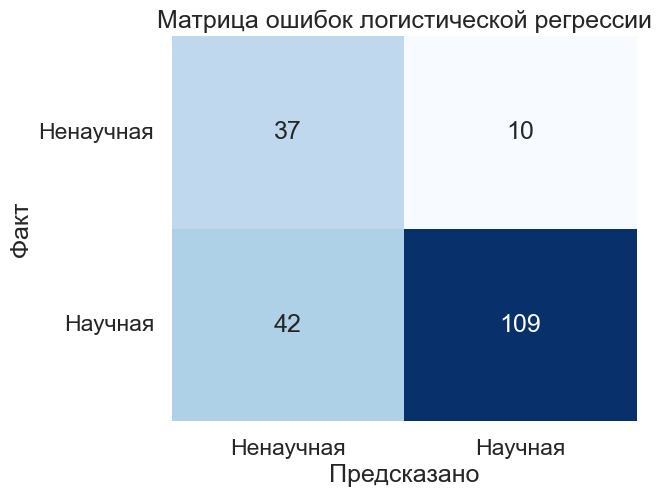

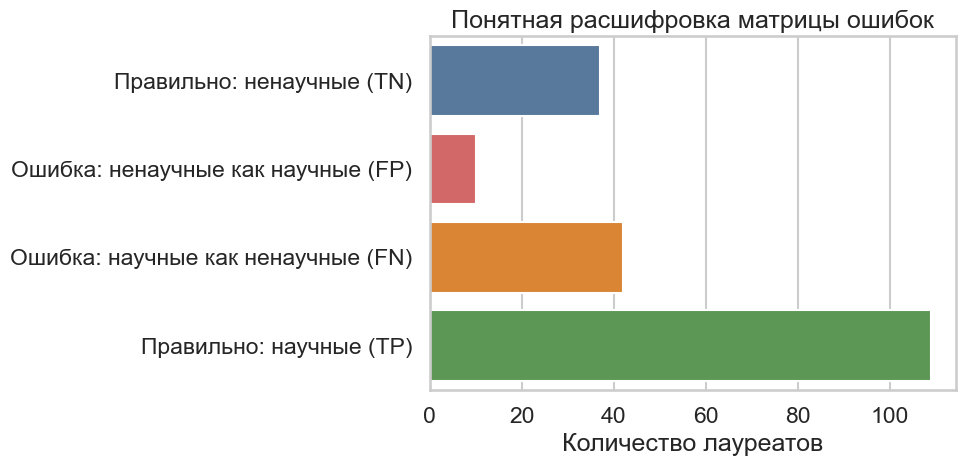

Пояснение:
- Синие/зеленые столбцы — правильные решения модели.
- Оранжевый/красный столбцы — ошибки модели.
- Чем больше правильных и меньше ошибочных столбцов, тем лучше классификатор.


In [32]:
reg_df = analysis_df.dropna(
    subset=[
        "age_awarded",
        "award_year_num",
        "prize_amount_log",
    ]
).copy()

reg_numeric_features = ["age_awarded", "award_year_num"]

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), reg_numeric_features),
    ]
)

X_reg = reg_df[reg_numeric_features]
y_reg = reg_df["prize_amount_log"]
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_model = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", LinearRegression()),
    ]
)

reg_model.fit(X_reg_train, y_reg_train)
y_reg_pred = reg_model.predict(X_reg_test)

regression_metrics = pd.Series(
    {
        "Коэффициент детерминации R²": r2_score(y_reg_test, y_reg_pred),
        "Средняя абсолютная ошибка": mean_absolute_error(y_reg_test, y_reg_pred),
        "Корень из средней квадратичной ошибки": np.sqrt(mean_squared_error(y_reg_test, y_reg_pred)),
    },
    name="Значение",
)

print("Множественная линейная регрессия: логарифм суммы премии от возраста и года лауреата")
display(regression_metrics.to_frame())

clf_df = analysis_df.dropna(
    subset=[
        "is_science",
        "age_awarded",
        "award_year_num",
        "prize_amount_log",
        "gender",
        "continent_group",
    ]
).copy()

clf_numeric_features = ["age_awarded", "award_year_num", "prize_amount_log", "prize_count"]
clf_categorical_features = ["gender", "continent_group"]

clf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), clf_numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), clf_categorical_features),
    ]
)

clf_df = analysis_df.dropna(
    subset=[
        "is_science",
        "birth_year",
        "award_year_num",
        "prize_amount_log",
        "prize_count",
        "gender",
        "continent_group",
    ]
).copy()

clf_numeric_features = ["birth_year", "award_year_num", "prize_amount_log", "prize_count"]
clf_categorical_features = ["gender", "continent_group"]

clf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            clf_numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            clf_categorical_features
        ),
    ]
)

X_clf = clf_df[clf_numeric_features + clf_categorical_features]
y_clf = clf_df["is_science"]

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf,
)

clf_model = Pipeline(
    steps=[
        ("preprocessor", clf_preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)

clf_model.fit(X_clf_train, y_clf_train)
y_clf_pred = clf_model.predict(X_clf_test)
y_clf_prob = clf_model.predict_proba(X_clf_test)[:, 1]

classification_metrics = pd.Series(
    {
        "Точность": accuracy_score(y_clf_test, y_clf_pred),
        "Точность положительного класса": precision_score(y_clf_test, y_clf_pred),
        "Полнота": recall_score(y_clf_test, y_clf_pred),
        "F1-мера": f1_score(y_clf_test, y_clf_pred),
        "ROC-AUC": roc_auc_score(y_clf_test, y_clf_prob),
    },
    name="Значение",
)

print("\nЛогистическая регрессия: классификация научных и ненаучных премий")
display(classification_metrics.to_frame())
print("\nОтчет по классификации")
report = classification_report(y_clf_test, y_clf_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.rename(index={"0": "Ненаучные премии", "1": "Научные премии", "accuracy": "Точность", "macro avg": "Макроусреднение", "weighted avg": "Взвешенное среднее"})
report_df = report_df.rename(columns={"precision": "Точность", "recall": "Полнота", "f1-score": "F1-мера", "support": "Число объектов"})
display(report_df)

cm = confusion_matrix(y_clf_test, y_clf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Матрица ошибок логистической регрессии")
plt.xlabel("Предсказано")
plt.ylabel("Факт")
plt.xticks([0.5, 1.5], ["Ненаучная", "Научная"])
plt.yticks([0.5, 1.5], ["Ненаучная", "Научная"], rotation=0)
plt.show()


tn, fp, fn, tp = cm.ravel()
cm_human = pd.Series(
    {
        "Правильно: ненаучные (TN)": tn,
        "Ошибка: ненаучные как научные (FP)": fp,
        "Ошибка: научные как ненаучные (FN)": fn,
        "Правильно: научные (TP)": tp,
    }
)

plt.figure(figsize=(10, 5))
sns.barplot(x=cm_human.values, y=cm_human.index, palette=["#4C78A8", "#E45756", "#F58518", "#54A24B"])
plt.title("Понятная расшифровка матрицы ошибок")
plt.xlabel("Количество лауреатов")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("Пояснение:")
print("- Синие/зеленые столбцы — правильные решения модели.")
print("- Оранжевый/красный столбцы — ошибки модели.")
print("- Чем больше правильных и меньше ошибочных столбцов, тем лучше классификатор.")

#### Матрица ошибок

Матрица ошибок показывает распределение правильных и ошибочных классификаций:

- True Positive (TP) - правильно определённые научные премии;
- True Negative (TN) - правильно определённые ненаучные премии;
- False Positive (FP) - ошибка: ненаучная классифицирована как научная;
- False Negative (FN) - ошибка: научная классифицирована как ненаучная.

#### Линейная регрессия

Исследуется взаимосвязь между годом награждения лауреата и годом его рождения. Мы проверяем гипотезу о том, что со временем средний год рождения лауреатов изменяется линейно.
$$
y = \beta_0 + \beta_1 x_1 + \varepsilon
$$

где:
- $y$ - предсказываемый год рождения лауреата,
- $x_1$ - год награждения (независимая переменная),
- $\beta_0$ - свободный член (интерцепт),
- $\beta_1$ - коэффициент наклона, показывающий скорость изменения года рождения,
- $\varepsilon$ - случайная ошибка.

Качество модели оценивается с помощью коэффициента детерминации:

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

Линейная регрессия: год рождения лауреата по году премии


,Значение
Коэффициент детерминации R²,0.876877
Средняя абсолютная ошибка,9.317493
Корень из средней квадратичной ошибки,11.285854


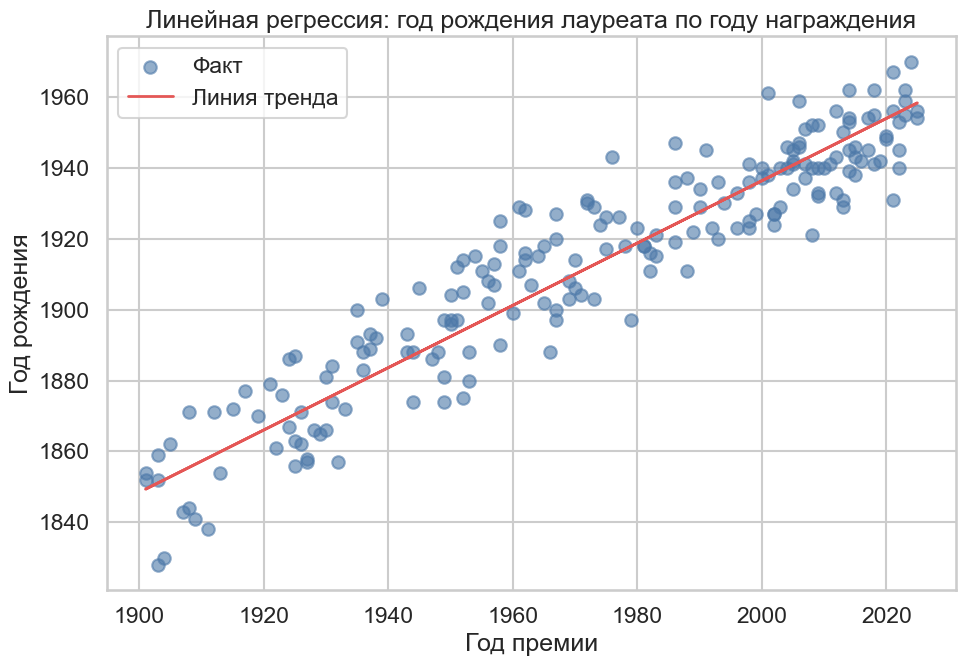

Пояснение:
- Синие точки показывают фактический год рождения лауреатов.
- Красная линия — предсказанная тенденция изменения года рождения со временем.
- Если линия хорошо описывает облако точек, модель работает хорошо.


In [33]:

simple_linear_df = analysis_df.dropna(subset=["birth_year", "award_year_num"]).copy()

linear_X = simple_linear_df[["award_year_num"]]
linear_y = simple_linear_df["birth_year"]
linear_X_train, linear_X_test, linear_y_train, linear_y_test = train_test_split(linear_X, linear_y, test_size=0.2, random_state=42)

simple_linear_model = LinearRegression()
simple_linear_model.fit(linear_X_train, linear_y_train)
linear_y_pred = simple_linear_model.predict(linear_X_test)

linear_regression_metrics = pd.Series(
    {
        "Коэффициент детерминации R²": r2_score(linear_y_test, linear_y_pred),
        "Средняя абсолютная ошибка": mean_absolute_error(linear_y_test, linear_y_pred),
        "Корень из средней квадратичной ошибки": np.sqrt(mean_squared_error(linear_y_test, linear_y_pred)),
    },
    name="Значение",
)

print("Линейная регрессия: год рождения лауреата по году премии")
display(linear_regression_metrics.to_frame())


plt.figure(figsize=(10, 7))
plt.scatter(linear_X_test["award_year_num"], linear_y_test, color="#4C78A8", alpha=0.6, label="Факт")
plt.plot(linear_X_test["award_year_num"], linear_y_pred, color="#E45756", linewidth=2, label="Линия тренда")
plt.title("Линейная регрессия: год рождения лауреата по году награждения")
plt.xlabel("Год премии")
plt.ylabel("Год рождения")
plt.legend()
plt.tight_layout()
plt.show()

print("Пояснение:")
print("- Синие точки показывают фактический год рождения лауреатов.")
print("- Красная линия — предсказанная тенденция изменения года рождения со временем.")
print("- Если линия хорошо описывает облако точек, модель работает хорошо.")

#### Логистическая регрессия

Вероятность принадлежности к классу определяется функцией:
$$
P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n)}}
$$
- $y = 1$ — научная премия,
- $y = 0$ — ненаучная.

Для оценки качества используются метрики:
- точность (Accuracy),
- полнота (Recall),
- точность положительного класса (Precision),
- F1-мера,
- ROC-AUC.

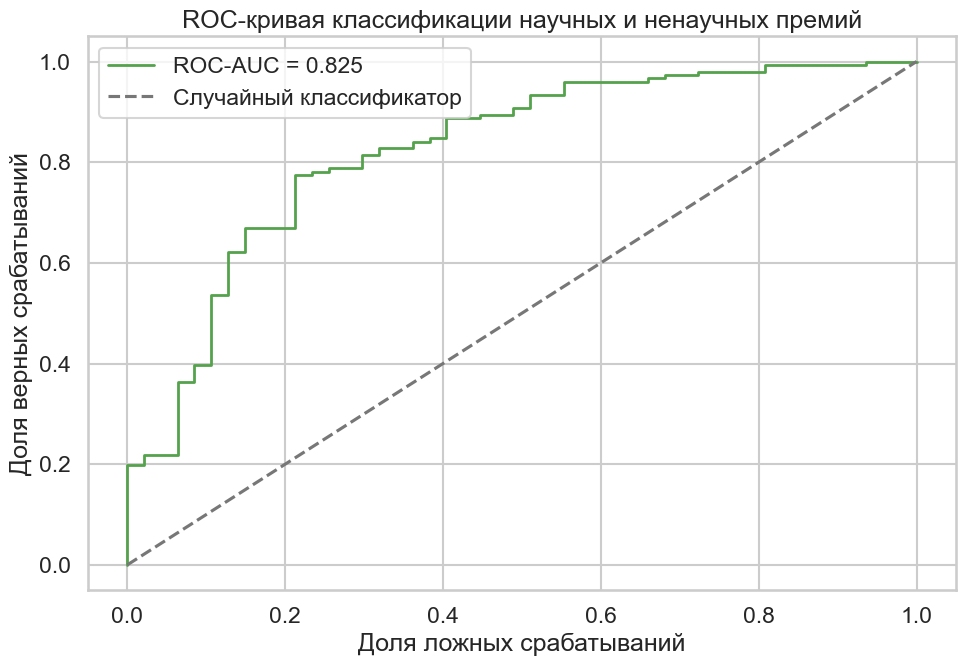

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_clf_test, y_clf_prob)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color="#54A24B", linewidth=2, label=f"ROC-AUC = {roc_auc_score(y_clf_test, y_clf_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="#777777", label="Случайный классификатор")
plt.title("ROC-кривая классификации научных и ненаучных премий")
plt.xlabel("Доля ложных срабатываний")
plt.ylabel("Доля верных срабатываний")
plt.legend()
plt.tight_layout()
plt.show()

#### Cечение многомерной логистической модели по переменной birth_year
$$
p(x)=\frac{1}{1+e^{-(\beta_0 + \beta_1 x)}}
$$



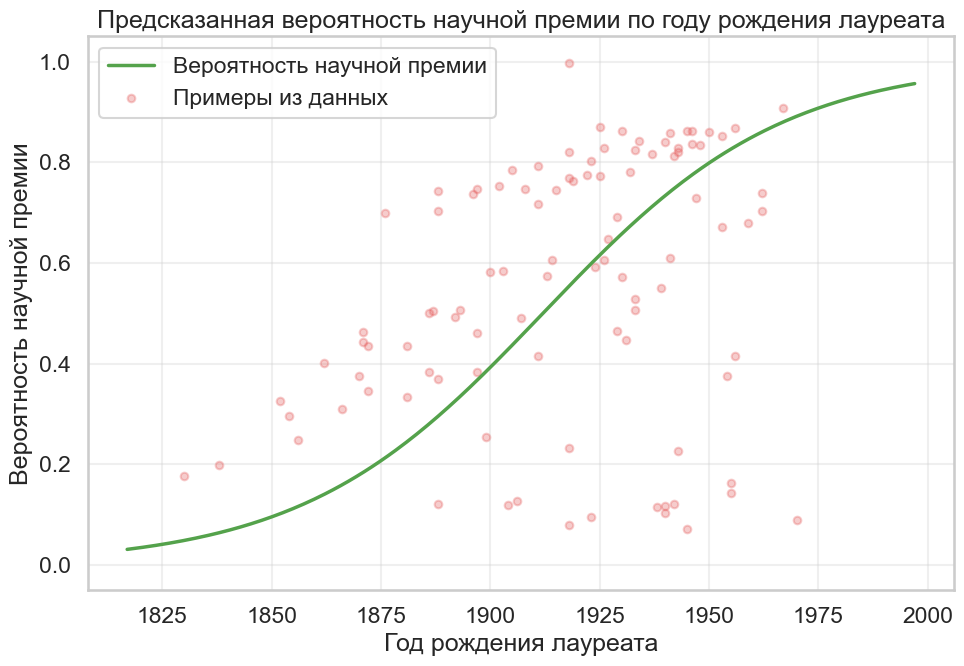

Пояснение графика:
- Кривая показывает предсказанную вероятность того, что премия является научной.
- По оси X отложен год рождения лауреата.
- Вероятность рассчитана при фиксированных остальных признаках.
- Точки показывают отдельные реальные наблюдения из выборки.


In [35]:
from scipy.special import expit

clf_feature_names = clf_model.named_steps["preprocessor"].get_feature_names_out()
birth_year_index = list(clf_feature_names).index("num__birth_year")

birth_year_range = np.linspace(clf_df["birth_year"].min(), clf_df["birth_year"].max(), 300)

predict_data = pd.DataFrame({
    "birth_year": birth_year_range,
    "award_year_num": [clf_df["award_year_num"].mean()] * len(birth_year_range),
    "prize_amount_log": [clf_df["prize_amount_log"].mean()] * len(birth_year_range),
    "prize_count": [clf_df["prize_count"].mean()] * len(birth_year_range),
    "gender": [clf_df["gender"].mode()[0]] * len(birth_year_range),
    "continent_group": [clf_df["continent_group"].mode()[0]] * len(birth_year_range),
})

probabilities = clf_model.predict_proba(predict_data)[:, 1]

plt.figure(figsize=(10, 7))
plt.plot(
    birth_year_range,
    probabilities,
    color="#54A24B",
    linewidth=2.5,
    label="Вероятность научной премии"
)

sample_data = clf_df.sample(min(100, len(clf_df)), random_state=42)
sample_predict = clf_model.predict_proba(
    sample_data[["birth_year", "award_year_num", "prize_amount_log", "prize_count", "gender", "continent_group"]]
)[:, 1]

plt.scatter(
    sample_data["birth_year"],
    sample_predict,
    alpha=0.3,
    s=30,
    color="#E45756",
    label="Примеры из данных"
)

plt.title("Предсказанная вероятность научной премии по году рождения лауреата")
plt.xlabel("Год рождения лауреата")
plt.ylabel("Вероятность научной премии")
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Пояснение графика:")
print("- Кривая показывает предсказанную вероятность того, что премия является научной.")
print("- По оси X отложен год рождения лауреата.")
print("- Вероятность рассчитана при фиксированных остальных признаках.")
print("- Точки показывают отдельные реальные наблюдения из выборки.")

#### Множественная линейная регрессия в 3D-пространстве

Для наглядного анализа структуры данных рассматривается зависимость суммы премии от года первой премии и категории награды.

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon
$$

где:
- $y$ — логарифм суммы премии,
- $x_1$ — год первой премии,
- $x_2$ — год рождения лауреата,
- $\beta_i$ — коэффициенты модели,
- $\varepsilon$ — случайная ошибка.

На графике:
- ось $X$ отражает год первой премии;
- ось $Y$ отражает категорию премии;
- ось $Z$ показывает логарифм суммы премии;
- цвет точек дублирует величину логарифма суммы премии.

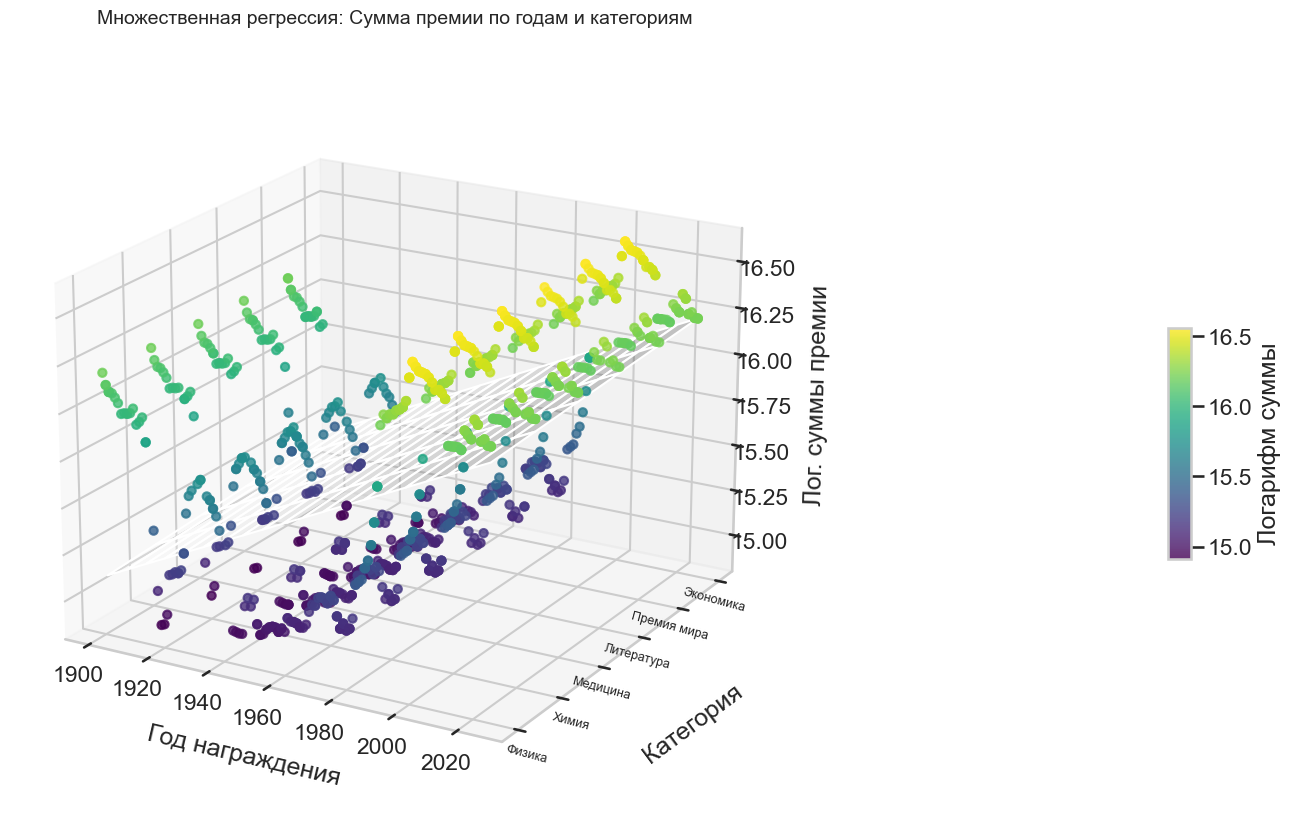

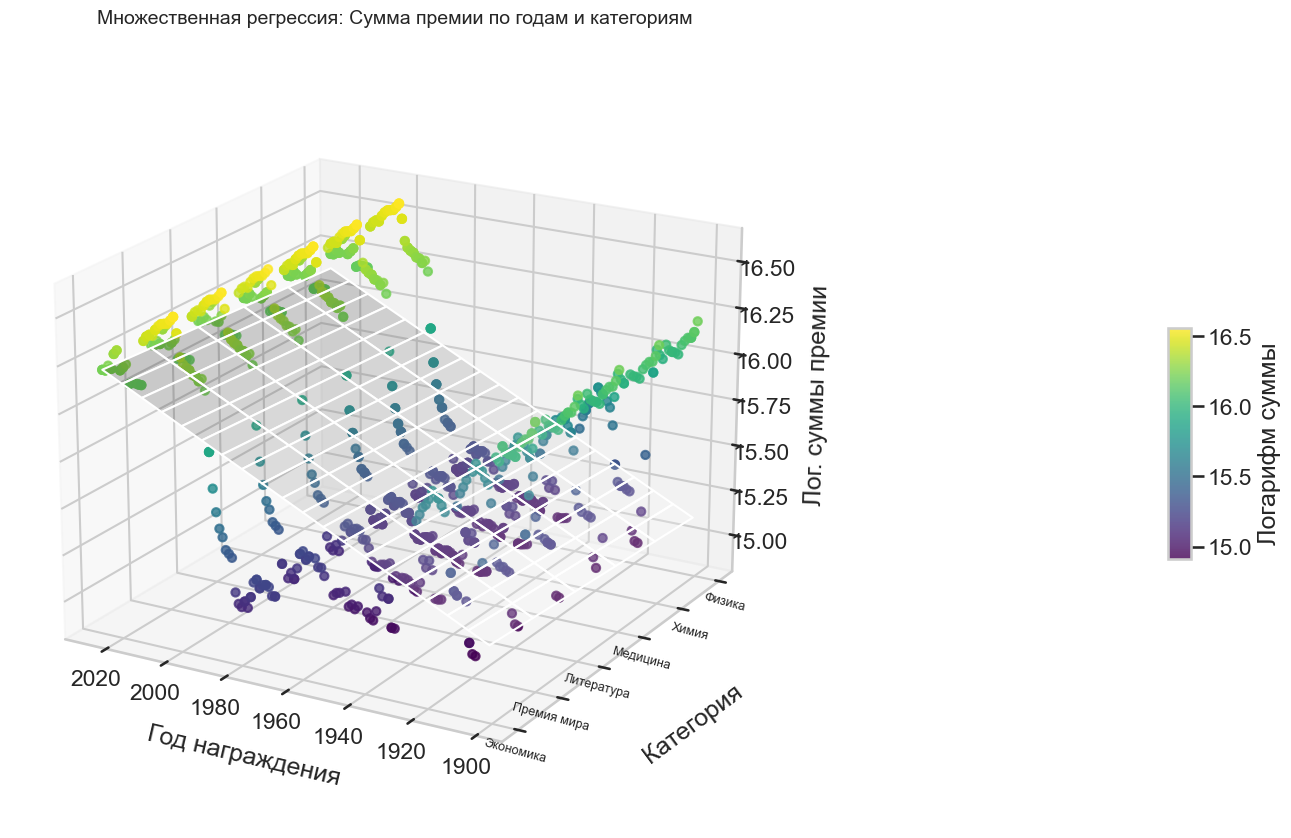

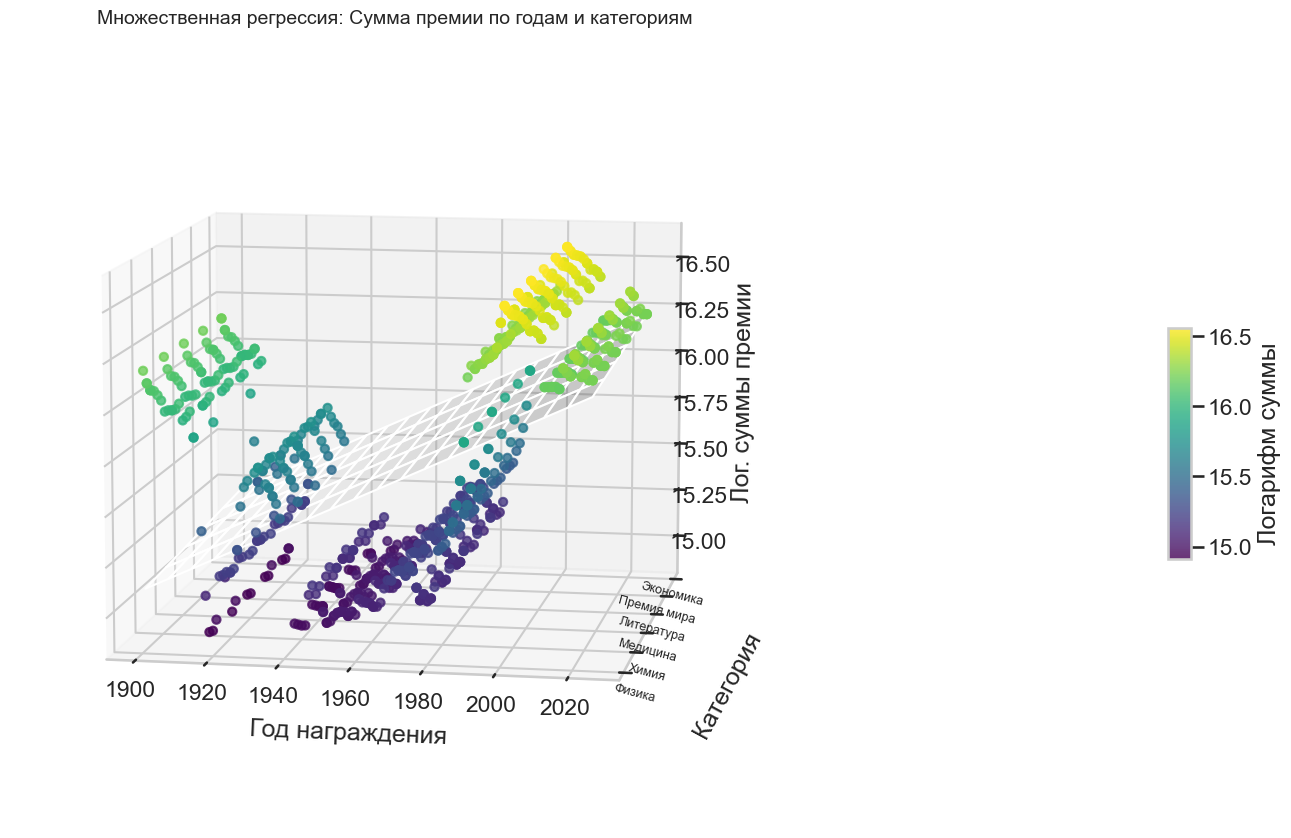

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

cat_viz_df = analysis_df.dropna(
    subset=["award_year_num", "first_category", "prize_amount_log"]
).copy()

def draw_3d(my_elev, my_azim):

    category_ru = {
        "Physics": "Физика",
        "Chemistry": "Химия",
        "Physiology or Medicine": "Медицина", 
        "Peace": "Премия мира",
        "Literature": "Литература",
        "Economic Sciences": "Экономика", 
    }

    cat_viz_df["category_ru"] = cat_viz_df["first_category"].map(category_ru).fillna(cat_viz_df["first_category"])

    category_order = ["Физика", "Химия", "Медицина", "Литература", "Премия мира", "Экономика"]
    present_categories = [c for c in category_order if c in cat_viz_df["category_ru"].unique()]
    cat_to_num = {cat: i for i, cat in enumerate(present_categories)}
    cat_viz_df["category_code"] = cat_viz_df["category_ru"].map(cat_to_num)

    X_plane = cat_viz_df[["award_year_num", "category_code"]]
    y_plane = cat_viz_df["prize_amount_log"]
    model_plane = LinearRegression().fit(X_plane, y_plane)

    x_range = np.linspace(cat_viz_df["award_year_num"].min(), cat_viz_df["award_year_num"].max(), 20)
    y_range = np.linspace(0, len(present_categories) - 1, len(present_categories))
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    Z_grid = model_plane.predict(np.c_[X_grid.ravel(), Y_grid.ravel()]).reshape(X_grid.shape)

    fig = plt.figure(figsize=(50, 10))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(X_grid, Y_grid, Z_grid, alpha=0.2, cmap="Greys", antialiased=True)

    sc = ax.scatter(
        cat_viz_df["award_year_num"],
        cat_viz_df["category_code"],
        cat_viz_df["prize_amount_log"],
        c=cat_viz_df["prize_amount_log"],
        cmap="viridis",
        s=35,
        alpha=0.8
    )



    ax.set_title("Множественная регрессия: Сумма премии по годам и категориям", pad=25, fontsize=14)
    ax.set_xlabel("Год награждения", labelpad=15)
    ax.set_ylabel("Категория", labelpad=25) 
    ax.set_zlabel("Лог. суммы премии", labelpad=15)

    ax.set_yticks(np.arange(len(present_categories)))

    ax.set_yticklabels(
        present_categories, 
        fontsize=10, 
        ha='right',   
        va='center',  
        rotation_mode='anchor'
    )


    ax.tick_params(axis='y', pad=10) 


    ax.set_yticks(list(cat_to_num.values()))
    ax.set_yticklabels(list(cat_to_num.keys()), fontsize=9, rotation=-15, ha='right')

    ax.view_init(elev=my_elev, azim=my_azim)

    fig.colorbar(sc, ax=ax, shrink=0.3, aspect=10, pad=0.1, label="Логарифм суммы")



    plt.tight_layout()
    plt.show()

draw_3d(20,-60)
draw_3d(20,120)
draw_3d(10,280)


1. Обоснование выбора моделей
Использованы наиболее значимые признаки из матрицы корреляций
2. Причина ошибок
Низкий $R^2$ и разброс точек на графиках объясняются историческими скачками и тем, что Нобелевский комитет меняет суммы редко и ступенчато

## V. Снижение размерности - Метод главных компонент (PCA)
Метод PCA позволил сократить размерность данных до двух главных компонент, которые объясняют около 70% общей дисперсии и выявляют скрытую структуру взаимосвязей между возрастом, годом награждения и суммой премии.

Метод главных компонент (PCA) Преобразование выполняется следующим образом:
$$
Z = XW
$$
где:
- $X$ - исходные данные, $W$ - матрица собственных векторов, $Z$ - новые признаки (главные компоненты).

Анализ главных компонент: доля объясненной дисперсии


,Доля объясненной дисперсии
Первая компонента,0.477533
Вторая компонента,0.214254


Суммарно первые две компоненты объясняют 0.692 дисперсии


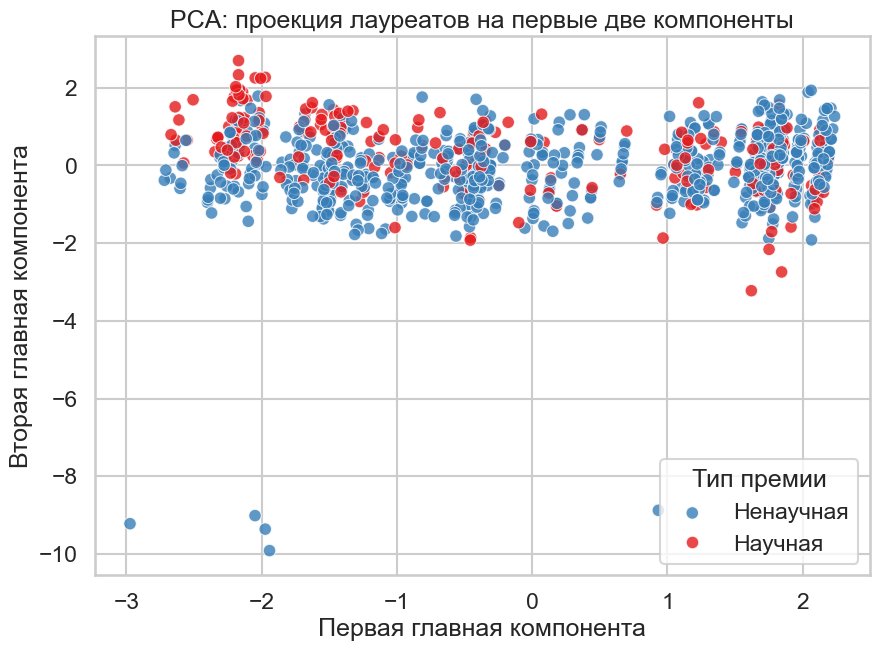

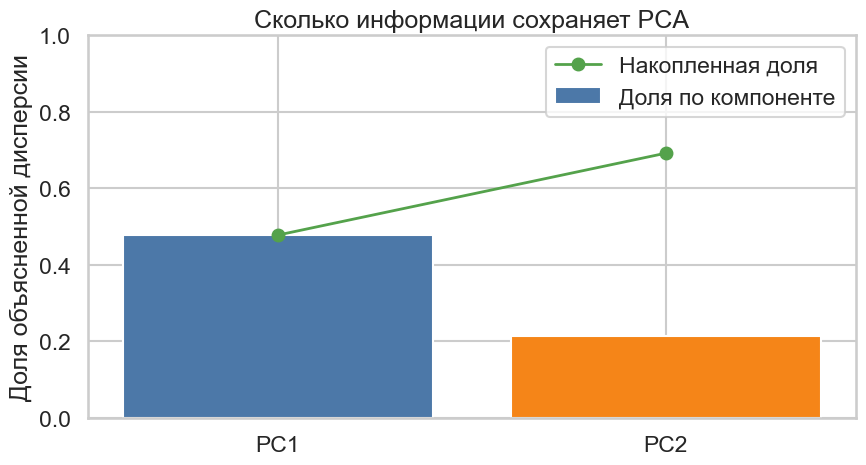

Пояснение по PCA простыми словами:
- PCA сжимает много признаков в несколько осей с минимальной потерей информации.
- PC1 — самая информативная ось, PC2 — следующая по важности.
- Накопленная линия показывает, сколько общей информации уже сохранено.
Лучшая модель ARIMA: порядок (2, 1, 2), AIC = 461.76
Оценка ARIMA на последних 10 годах


,Значение
Средняя абсолютная ошибка,1.183185
Корень из средней квадратичной ошибки,1.437700


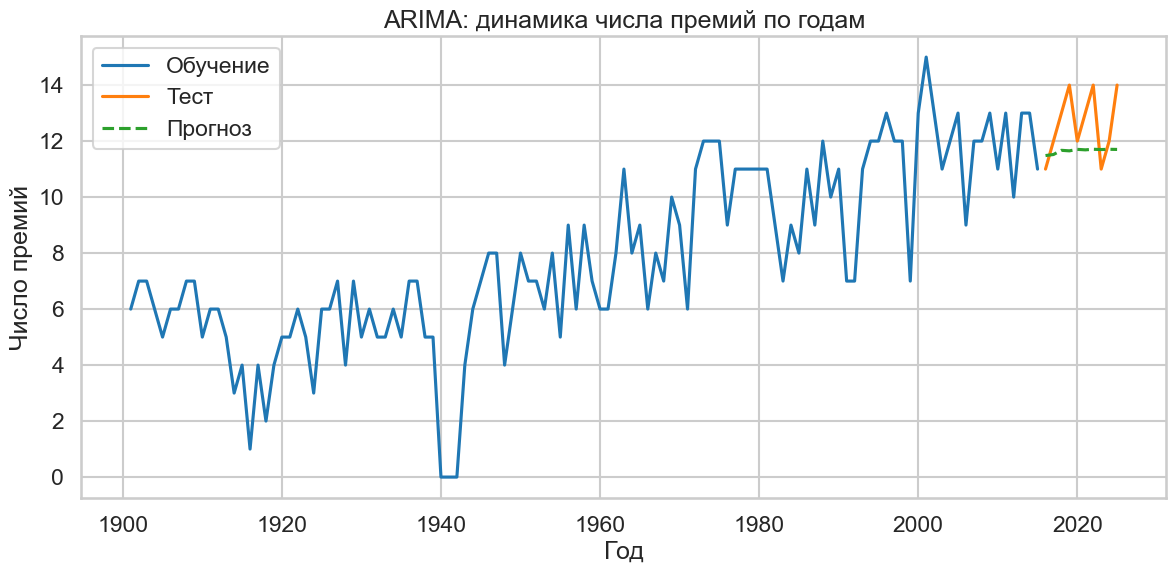

Пояснение по ARIMA простыми словами:
- ARIMA — модель, которая учится на прошлых значениях временного ряда и прогнозирует будущие.
- Обучение (синяя линия): историческая часть ряда, на которой модель настраивается.
- Тест (оранжевая линия): реальные значения, которые модель не видела при обучении.
- Прогноз (зеленая пунктирная линия): предсказания модели на тестовом отрезке.
- Чем ближе прогноз к тесту, тем лучше модель улавливает динамику ряда.
Прогноз на следующие 5 лет


,Год,Предсказанное число премий
0,2026,11.482820
1,2027,11.520403
2,2028,11.670081
3,2029,11.651329
4,2030,11.704029


In [37]:
pca_df = analysis_df.dropna(
    subset=["birth_year", "award_year_num", "age_awarded", "prize_amount_log", "prize_count", "is_science"]
).copy()

pca_features = ["birth_year", "award_year_num", "age_awarded", "prize_amount_log", "prize_count"]
X_pca = pca_df[pca_features]
X_pca_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_pca_scaled)
pca_df["pc1"] = pca_components[:, 0]
pca_df["pc2"] = pca_components[:, 1]

print("Анализ главных компонент: доля объясненной дисперсии")
display(pd.Series(pca.explained_variance_ratio_, index=["Первая компонента", "Вторая компонента"], name="Доля объясненной дисперсии").to_frame())
print(f"Суммарно первые две компоненты объясняют {pca.explained_variance_ratio_.sum():.3f} дисперсии")

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="pc1", y="pc2", hue="is_science", palette="Set1", alpha=0.8)
plt.title("PCA: проекция лауреатов на первые две компоненты")
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.legend(title="Тип премии", labels=["Ненаучная", "Научная"])
plt.show()

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(9, 5))
plt.bar(["PC1", "PC2"], explained, color=["#4C78A8", "#F58518"], label="Доля по компоненте")
plt.plot(["PC1", "PC2"], cumulative, marker="o", color="#54A24B", linewidth=2, label="Накопленная доля")
plt.title("Сколько информации сохраняет PCA")
plt.ylabel("Доля объясненной дисперсии")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

print("Пояснение по PCA простыми словами:")
print("- PCA сжимает много признаков в несколько осей с минимальной потерей информации.")
print("- PC1 — самая информативная ось, PC2 — следующая по важности.")
print("- Накопленная линия показывает, сколько общей информации уже сохранено.")

# Анализ временного ряда: число присужденных премий по годам.
yearly_series = prize_df.copy()
yearly_series["award_year"] = pd.to_numeric(yearly_series["award_year"], errors="coerce")
yearly_series = yearly_series.dropna(subset=["award_year"])
yearly_counts = yearly_series.groupby("award_year").size().sort_index()
full_years = pd.Index(range(int(yearly_counts.index.min()), int(yearly_counts.index.max()) + 1), name="award_year")
yearly_counts = yearly_counts.reindex(full_years, fill_value=0).astype(float)

forecast_horizon = 10
train_series = yearly_counts.iloc[:-forecast_horizon]
test_series = yearly_counts.iloc[-forecast_horizon:]

best_order = None
best_aic = np.inf
best_model = None

for p in range(0, 3):
    for d in range(0, 2):
        for q in range(0, 3):
            try:
                candidate = ARIMA(
                    train_series,
                    order=(p, d, q),
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit()
                if candidate.aic < best_aic:
                    best_aic = candidate.aic
                    best_order = (p, d, q)
                    best_model = candidate
            except Exception:
                continue

if best_model is None:
    best_order = (1, 1, 1)
    best_model = ARIMA(
        train_series,
        order=best_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()
    best_aic = best_model.aic

print(f"Лучшая модель ARIMA: порядок {best_order}, AIC = {best_aic:.2f}")

test_forecast = best_model.forecast(steps=forecast_horizon)
forecast_metrics = pd.Series(
    {
        "Средняя абсолютная ошибка": mean_absolute_error(test_series, test_forecast),
        "Корень из средней квадратичной ошибки": np.sqrt(mean_squared_error(test_series, test_forecast)),
    },
    name="Значение",
)
print("Оценка ARIMA на последних 10 годах")
display(forecast_metrics.to_frame())

plt.figure(figsize=(14, 6))
plt.plot(train_series.index, train_series.values, label="Обучение", color="#1f77b4")
plt.plot(test_series.index, test_series.values, label="Тест", color="#ff7f0e")
plt.plot(test_series.index, test_forecast.values, label="Прогноз", color="#2ca02c", linestyle="--")
plt.title("ARIMA: динамика числа премий по годам")
plt.xlabel("Год")
plt.ylabel("Число премий")
plt.legend()
plt.show()

print("Пояснение по ARIMA простыми словами:")
print("- ARIMA — модель, которая учится на прошлых значениях временного ряда и прогнозирует будущие.")
print("- Обучение (синяя линия): историческая часть ряда, на которой модель настраивается.")
print("- Тест (оранжевая линия): реальные значения, которые модель не видела при обучении.")
print("- Прогноз (зеленая пунктирная линия): предсказания модели на тестовом отрезке.")
print("- Чем ближе прогноз к тесту, тем лучше модель улавливает динамику ряда.")

future_steps = 5
future_forecast = best_model.forecast(steps=future_steps)
print("Прогноз на следующие 5 лет")
display(pd.DataFrame({"Год": range(int(yearly_counts.index.max()) + 1, int(yearly_counts.index.max()) + 1 + future_steps), "Предсказанное число премий": future_forecast.values}))

### VI. Модель ARIMA

Для анализа временного ряда используется модель ARIMA:
$$
ARIMA(p,d,q): \quad \Delta^d y_t =
c + \sum_{i=1}^{p} \phi_i y_{t-i}
+ \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
+ \varepsilon_t
$$
где:
- $p$ - порядок авторегрессии,
- $d$ - порядок дифференцирования,
- $q$ - порядок скользящего среднего.

### Дополнительный анализ: типы премий и пол внутри категорий

Этот блок нужен, чтобы увидеть не только общую структуру данных, но и различия между категориями внутри пола. Здесь мы сравниваем количество мужчин и женщин в каждой категории и дополнительно смотрим долю женщин внутри категорий.

Главный вопрос: в каких категориях женское представительство выше, а где сохраняется сильный дисбаланс в пользу мужчин?

Сравнение пола внутри категорий


gender,Мужчины,Женщины,Всего,Доля женщин
first_category,,,,
Физиология или медицина,218,14,232,0.060345
Физика,224,5,229,0.021834
Химия,190,7,197,0.035533
Литература,104,18,122,0.147541
Премия мира,91,20,111,0.180180
Экономические науки,96,3,99,0.030303


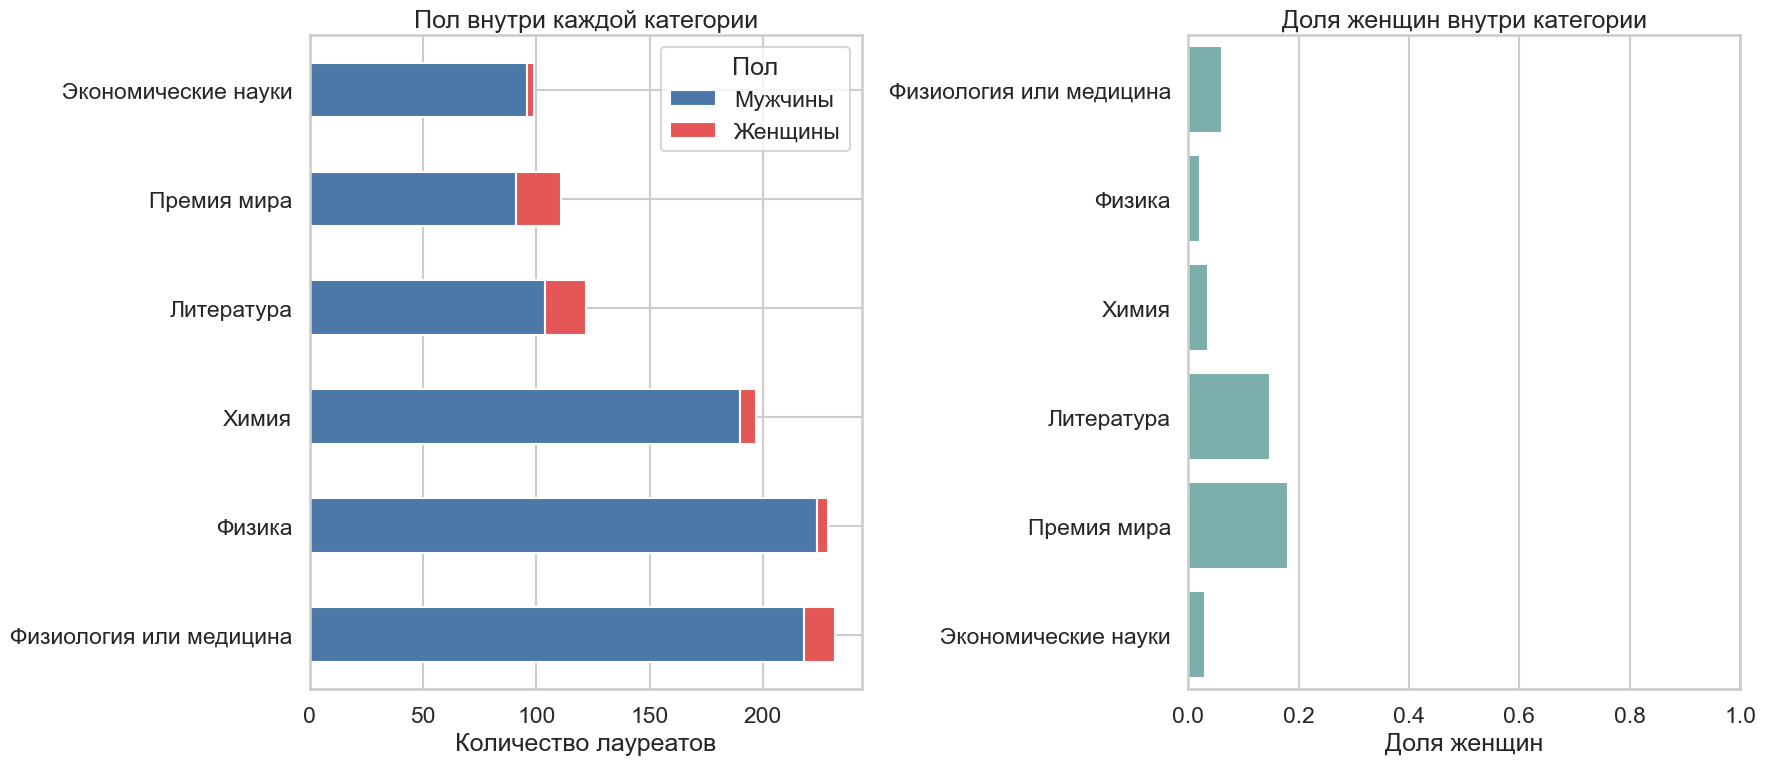


Выводы по дополнительному анализу:
- В гуманитарных и миротворческих категориях доля женщин заметно выше, чем в научных.
- В физике, химии и экономических науках сохраняется сильное доминирование мужчин.
- Анализ внутри категорий дополняет общий график по полу и показывает, что дисбаланс неодинаков в разных типах премий.


In [38]:
category_gender = analysis_df.dropna(subset=["first_category", "gender"]).copy()
category_gender_counts = pd.crosstab(category_gender["first_category"], category_gender["gender"])
category_gender_counts = category_gender_counts.reindex(columns=["male", "female"], fill_value=0)
category_gender_counts["total"] = category_gender_counts.sum(axis=1)
category_gender_counts["female_share"] = category_gender_counts["female"] / category_gender_counts["total"]
category_gender_counts = category_gender_counts.sort_values("total", ascending=False)

category_gender_counts_ru = category_gender_counts.copy()
category_gender_counts_ru.index = category_gender_counts_ru.index.map(category_ru)
category_gender_counts_ru = category_gender_counts_ru.rename(columns={"male": "Мужчины", "female": "Женщины", "total": "Всего", "female_share": "Доля женщин"})

print("Сравнение пола внутри категорий")
display(category_gender_counts_ru)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plot_df = category_gender_counts[["male", "female"]].copy()
plot_df.index = plot_df.index.map(category_ru)
plot_df = plot_df.rename(columns={"male": "Мужчины", "female": "Женщины"})
plot_df[["Мужчины", "Женщины"]].plot(kind="barh", stacked=True, ax=axes[0], color=["#4C78A8", "#E45756"])
axes[0].set_title("Пол внутри каждой категории")
axes[0].set_xlabel("Количество лауреатов")
axes[0].set_ylabel("")
axes[0].legend(title="Пол")

share_df = category_gender_counts[["female_share"]].copy()
share_df.index = share_df.index.map(category_ru)
sns.barplot(x=share_df["female_share"].values, y=share_df.index, ax=axes[1], color="#72B7B2")
axes[1].set_title("Доля женщин внутри категории")
axes[1].set_xlabel("Доля женщин")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

print("\nВыводы по дополнительному анализу:")
print("- В гуманитарных и миротворческих категориях доля женщин заметно выше, чем в научных.")
print("- В физике, химии и экономических науках сохраняется сильное доминирование мужчин.")
print("- Анализ внутри категорий дополняет общий график по полу и показывает, что дисбаланс неодинаков в разных типах премий.")

### VII. Интерпретация результатов, выводы и ограничения

**Ключевые наблюдения:**

- распределение лауреатов по категориям сильно неравномерно, при этом научные категории доминируют;
- женщины представлены существенно реже мужчин, что видно и на уровне общего распределения, и в разрезе категорий;
- дополнительный анализ показал, что внутри категорий доля женщин выше в гуманитарных и миротворческих премиях, а в физических, химических и экономических науках сохраняется сильное преобладание мужчин;
- возраст на момент награждения варьируется заметно, а наиболее зрелые лауреаты обычно встречаются в литературе и премии мира;
- временной ряд числа присужденных премий по годам имеет выраженную динамику, поэтому ARIMA применима к агрегированному годовому счётчику;
- PCA показывает, что часть вариации хорошо объясняется несколькими числовыми признаками, но полная структура данных остаётся многомерной.

**Ограничения анализа:**

- часть записей содержит пропуски в биографических и аффилиационных полях;
- классификационная задача построена на производном признаке `is_science`, поэтому она иллюстрирует методологию, а не самостоятельную предметную задачу;
- ARIMA применена к агрегированному годовому ряду, а не к индивидуальным лауреатам;
- исторические изменения правил присуждения премий и инфляция делают прямое сравнение денежных сумм ограниченно интерпретируемым.

### VIII. Библиография и вклад участников

**Источники данных и методические материалы:**

- Nobel Prize API: `https://api.nobelprize.org/2.1/laureates`
- `reference/Lucrare individuală de grup 2.pdf`
- `reference/C8-C11 MSAD.pdf`
- документация `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `statsmodels`

**Вклад членов команды:**

- Григорий Зайка — постановка темы, загрузка данных, очистка и построение признаков.
- Артур Мамалига — EDA, визуализации и интерпретация распределений.
- Анатолий Курилов — регрессия, классификация, PCA, ARIMA и сводные выводы.
